# Análise Temporal Completa: TODAS as Classificações

## 📊 Objetivo

Analisar o comportamento temporal de **TODAS as 4 classificações**:
- ✅ **POSITIVA**
- ⚪ **NEUTRA**
- ❌ **NEGATIVA**
- 📢 **PUBLICIDADE**

## 🎯 Por que incluir PUBLICIDADE?

- Ver se campanhas publicitárias correlacionam com mudanças de sentimento
- Identificar períodos de maior/menor investimento em comunicação
- Entender se mudanças são orgânicas ou impulsionadas por publicidade

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuração
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Carregar Dados

In [2]:
# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar
df = pd.read_excel(url, engine='openpyxl')

print(f"✅ {len(df):,} registros carregados")
print(f"   Período: {df['Data'].min()} a {df['Data'].max()}")

✅ 12,317 registros carregados
   Período: 2024-03-31 00:00:00 a 2025-03-31 00:00:00


In [3]:
# Preparação básica
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')

print("✅ Dados preparados")

✅ Dados preparados


## 2. Criar Análise Temporal Completa

**IMPORTANTE**: Usamos `df` completo (não `df_sentiment`) para incluir PUBLICIDADE

In [4]:
# Agrupar por mês e classificação
temporal_all = df.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_all = temporal_all.reset_index()
temporal_all['Data'] = temporal_all['Ano_Mes'].dt.to_timestamp()

# Garantir que todas as 4 colunas existam
for col in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
    if col not in temporal_all.columns:
        temporal_all[col] = 0

# Totais
temporal_all['Total_Geral'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].sum(axis=1)
temporal_all['Total_Sentimento'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)

# Percentuais
temporal_all['Pct_POSITIVA'] = (temporal_all['POSITIVA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_NEUTRA'] = (temporal_all['NEUTRA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_NEGATIVA'] = (temporal_all['NEGATIVA'] / temporal_all['Total_Geral'] * 100)
temporal_all['Pct_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / temporal_all['Total_Geral'] * 100)

print("✅ Análise temporal criada")
print(f"\nPeríodo analisado: {temporal_all['Ano_Mes'].min()} a {temporal_all['Ano_Mes'].max()}")
print(f"Total de meses: {len(temporal_all)}")

✅ Análise temporal criada

Período analisado: 2024-03 a 2025-03
Total de meses: 13


In [5]:
# Visualizar últimos 12 meses
print("📊 Últimos 12 meses:")
display(temporal_all[['Ano_Mes', 'POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE', 'Total_Geral']].tail(12))

📊 Últimos 12 meses:


Classificação,Ano_Mes,POSITIVA,NEUTRA,NEGATIVA,PUBLICIDADE,Total_Geral
1,2024-04,394,267,89,0,750
2,2024-05,547,1306,212,0,2065
3,2024-06,234,274,110,0,618
4,2024-07,292,321,139,0,752
5,2024-08,258,325,129,0,712
6,2024-09,556,73,91,0,720
7,2024-10,391,160,131,1,683
8,2024-11,366,276,390,0,1032
9,2024-12,476,315,286,1,1078
10,2025-01,558,341,365,0,1264


## 3. Visualização 1: Números Absolutos

### Mostra a evolução bruta de cada classificação

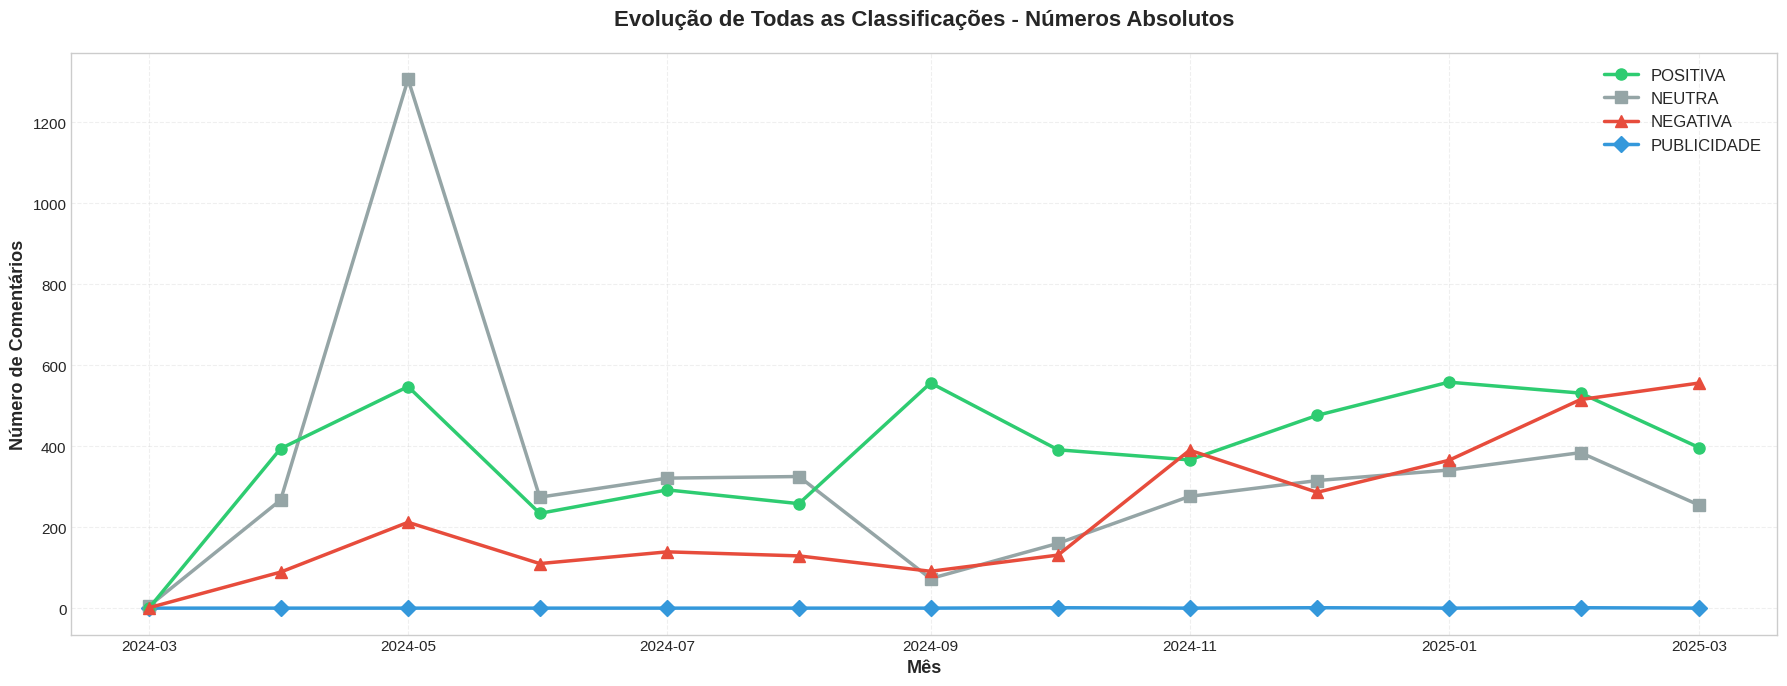

💡 INTERPRETAÇÃO:
   ✅ POSITIVA crescendo MAIS que NEGATIVA → NSS subindo
   ❌ NEGATIVA crescendo em termos absolutos → Mais reclamações
   📢 PUBLICIDADE alta → Mais investimento em comunicação
   📉 PUBLICIDADE baixa → Menos ação de comunicação


In [6]:
fig, ax = plt.subplots(figsize=(18, 7))

# Plotar todas as 4 classificações
ax.plot(temporal_all['Data'], temporal_all['POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='POSITIVA', zorder=4)
ax.plot(temporal_all['Data'], temporal_all['NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='NEUTRA', zorder=3)
ax.plot(temporal_all['Data'], temporal_all['NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='NEGATIVA', zorder=5)
ax.plot(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='PUBLICIDADE', zorder=2)

# Setembro 2025
setembro_2025_ts = pd.Timestamp('2025-09-01')
if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', 
               alpha=0.6, linewidth=3, label='Setembro/2025', zorder=1)

ax.set_title('Evolução de Todas as Classificações - Números Absolutos', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de Comentários', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   ✅ POSITIVA crescendo MAIS que NEGATIVA → NSS subindo")
print("   ❌ NEGATIVA crescendo em termos absolutos → Mais reclamações")
print("   📢 PUBLICIDADE alta → Mais investimento em comunicação")
print("   📉 PUBLICIDADE baixa → Menos ação de comunicação")

## 4. Visualização 2: Percentuais

### Mostra a proporção de cada classificação no total

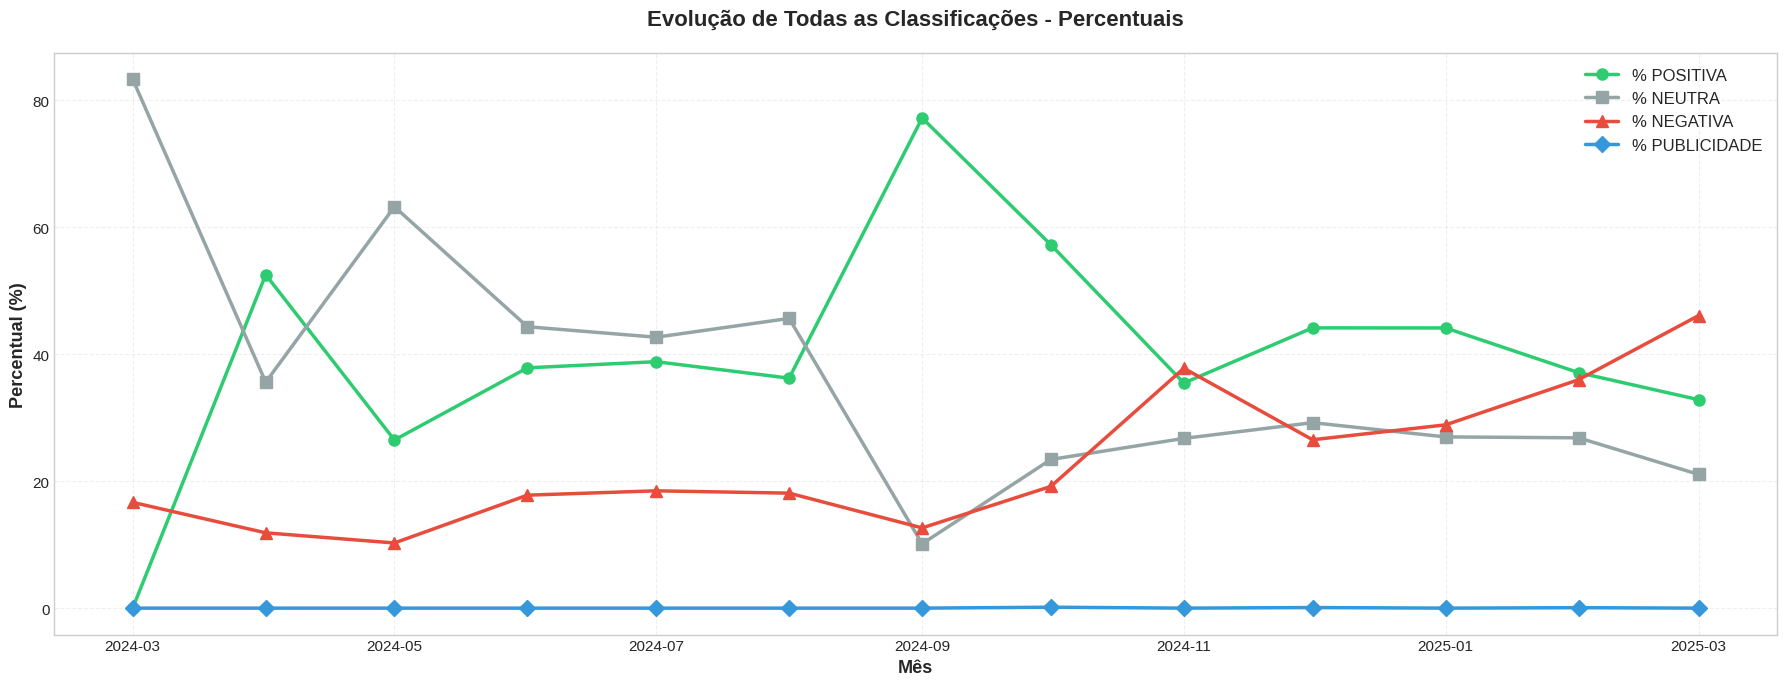

💡 INTERPRETAÇÃO:
   📊 Se % PUBLICIDADE aumentou → Mais material publicitário
   ✅ Se % NEGATIVA caiu → Menos reclamações proporcionalmente
   📈 Se % POSITIVA subiu → Mais satisfação relativa


In [7]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(temporal_all['Data'], temporal_all['Pct_POSITIVA'], 
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='% POSITIVA')
ax.plot(temporal_all['Data'], temporal_all['Pct_NEUTRA'], 
        marker='s', linewidth=2.5, markersize=8, color='#95a5a6', label='% NEUTRA')
ax.plot(temporal_all['Data'], temporal_all['Pct_NEGATIVA'], 
        marker='^', linewidth=2.5, markersize=8, color='#e74c3c', label='% NEGATIVA')
ax.plot(temporal_all['Data'], temporal_all['Pct_PUBLICIDADE'], 
        marker='D', linewidth=2.5, markersize=8, color='#3498db', label='% PUBLICIDADE')

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', 
               alpha=0.6, linewidth=3, label='Setembro/2025')

ax.set_title('Evolução de Todas as Classificações - Percentuais', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   📊 Se % PUBLICIDADE aumentou → Mais material publicitário")
print("   ✅ Se % NEGATIVA caiu → Menos reclamações proporcionalmente")
print("   📈 Se % POSITIVA subiu → Mais satisfação relativa")

## 5. Visualização 3: Área Empilhada (100%)

### Mostra a composição total ao longo do tempo

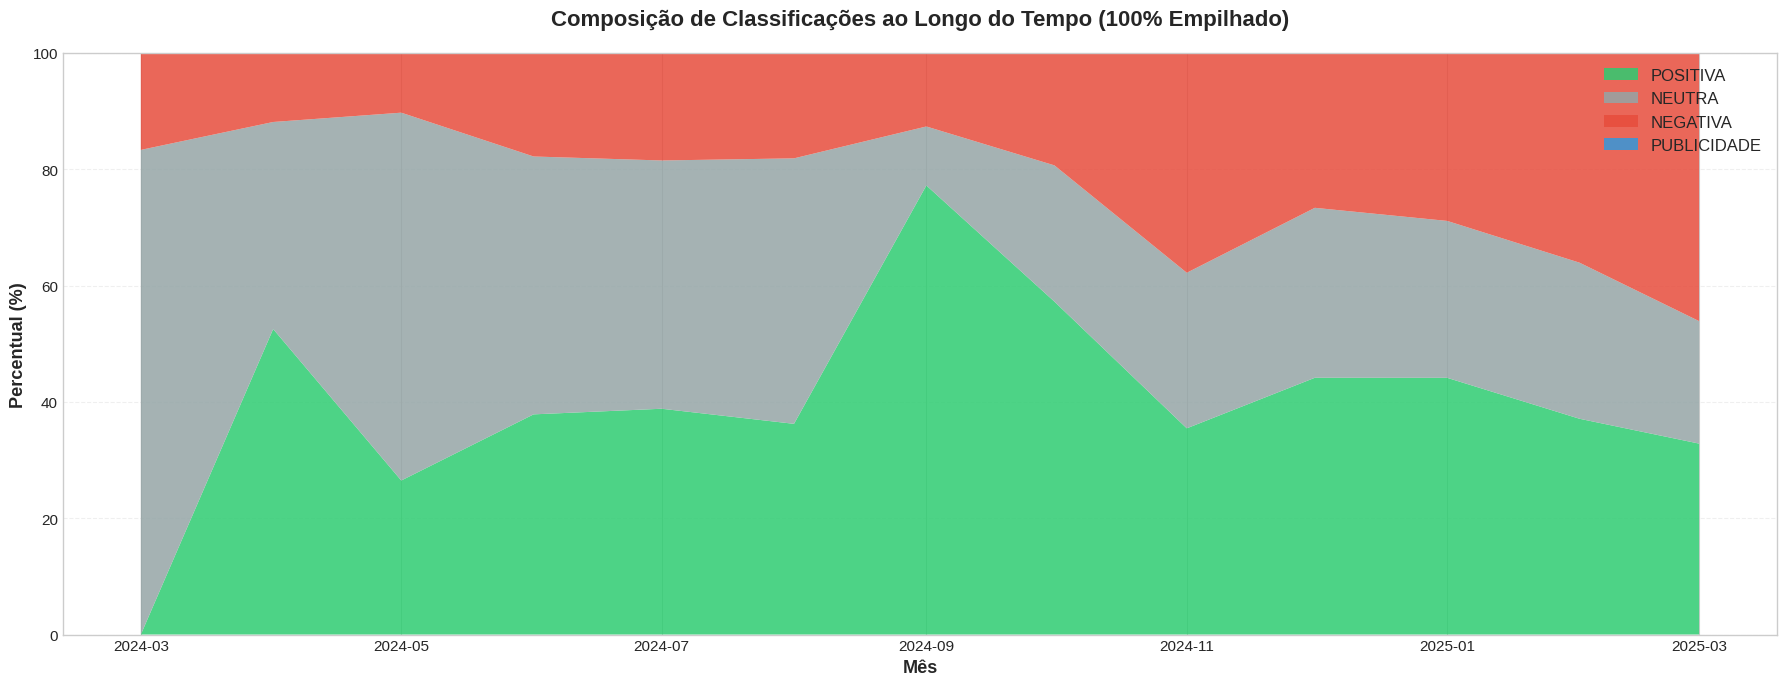

💡 INTERPRETAÇÃO:
   🟢 Área VERDE (POSITIVA) crescendo → Mais satisfação
   🔴 Área VERMELHA (NEGATIVA) diminuindo → Menos reclamações
   🔵 Área AZUL (PUBLICIDADE) crescendo → Mais investimento
   ⚪ Área CINZA (NEUTRA) estável → Mantém proporção


In [8]:
fig, ax = plt.subplots(figsize=(18, 7))

ax.stackplot(temporal_all['Data'], 
             temporal_all['Pct_POSITIVA'],
             temporal_all['Pct_NEUTRA'],
             temporal_all['Pct_NEGATIVA'],
             temporal_all['Pct_PUBLICIDADE'],
             labels=['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE'],
             colors=['#2ecc71', '#95a5a6', '#e74c3c', '#3498db'],
             alpha=0.85)

if setembro_2025_ts in temporal_all['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', 
               alpha=0.9, linewidth=4, zorder=5)
    ax.text(setembro_2025_ts, 103, 'Setembro/2025', 
            ha='center', fontsize=12, fontweight='bold', 
            color='darkgoldenrod', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.8))

ax.set_title('Composição de Classificações ao Longo do Tempo (100% Empilhado)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=12, framealpha=0.95)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   🟢 Área VERDE (POSITIVA) crescendo → Mais satisfação")
print("   🔴 Área VERMELHA (NEGATIVA) diminuindo → Menos reclamações")
print("   🔵 Área AZUL (PUBLICIDADE) crescendo → Mais investimento")
print("   ⚪ Área CINZA (NEUTRA) estável → Mantém proporção")

## 6. Visualização 4: Painéis Individuais

### Cada classificação em seu próprio painel para análise detalhada

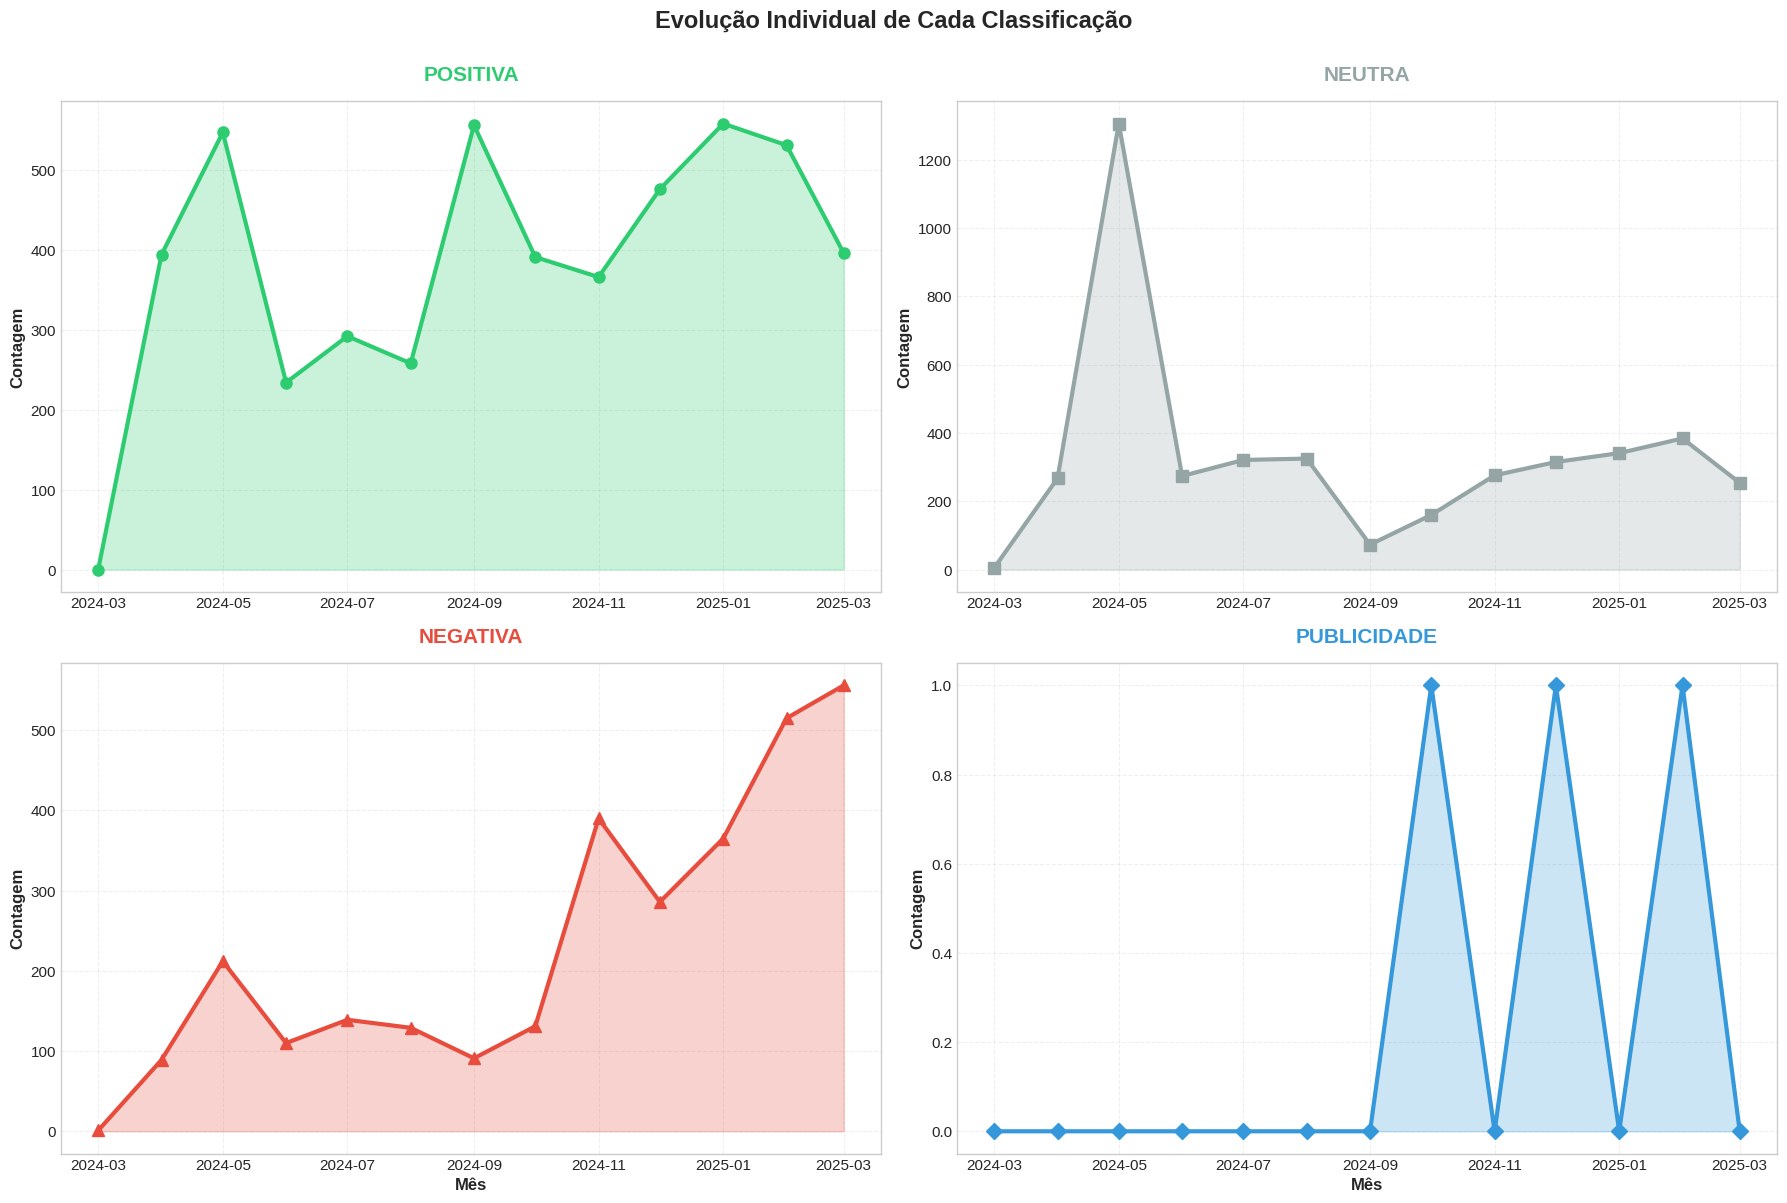

💡 INTERPRETAÇÃO:
   Cada painel mostra uma classificação isolada
   Facilita identificar padrões específicos em cada tipo


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Painel 1: POSITIVA
axes[0, 0].plot(temporal_all['Data'], temporal_all['POSITIVA'], 
                marker='o', linewidth=3, color='#2ecc71', markersize=8)
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=2)
axes[0, 0].set_title('POSITIVA', fontsize=15, fontweight='bold', color='#2ecc71', pad=15)
axes[0, 0].set_ylabel('Contagem', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].fill_between(temporal_all['Data'], temporal_all['POSITIVA'], 
                         alpha=0.25, color='#2ecc71')

# Painel 2: NEUTRA
axes[0, 1].plot(temporal_all['Data'], temporal_all['NEUTRA'], 
                marker='s', linewidth=3, color='#95a5a6', markersize=8)
if setembro_2025_ts in temporal_all['Data'].values:
    axes[0, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=2)
axes[0, 1].set_title('NEUTRA', fontsize=15, fontweight='bold', color='#95a5a6', pad=15)
axes[0, 1].set_ylabel('Contagem', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].fill_between(temporal_all['Data'], temporal_all['NEUTRA'], 
                         alpha=0.25, color='#95a5a6')

# Painel 3: NEGATIVA
axes[1, 0].plot(temporal_all['Data'], temporal_all['NEGATIVA'], 
                marker='^', linewidth=3, color='#e74c3c', markersize=8)
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=2)
axes[1, 0].set_title('NEGATIVA', fontsize=15, fontweight='bold', color='#e74c3c', pad=15)
axes[1, 0].set_xlabel('Mês', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Contagem', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].fill_between(temporal_all['Data'], temporal_all['NEGATIVA'], 
                         alpha=0.25, color='#e74c3c')

# Painel 4: PUBLICIDADE
axes[1, 1].plot(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
                marker='D', linewidth=3, color='#3498db', markersize=8)
if setembro_2025_ts in temporal_all['Data'].values:
    axes[1, 1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.6, linewidth=2)
axes[1, 1].set_title('PUBLICIDADE', fontsize=15, fontweight='bold', color='#3498db', pad=15)
axes[1, 1].set_xlabel('Mês', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Contagem', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].fill_between(temporal_all['Data'], temporal_all['PUBLICIDADE'], 
                         alpha=0.25, color='#3498db')

plt.suptitle('Evolução Individual de Cada Classificação', 
             fontsize=17, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("💡 INTERPRETAÇÃO:")
print("   Cada painel mostra uma classificação isolada")
print("   Facilita identificar padrões específicos em cada tipo")

## 7. Análise de Mudanças em Setembro

In [10]:
# Filtrar dados de setembro e agosto
setembro_mes = pd.Period('2025-09', freq='M')
agosto_mes = pd.Period('2025-08', freq='M')

dados_setembro = temporal_all[temporal_all['Ano_Mes'] == setembro_mes]
dados_agosto = temporal_all[temporal_all['Ano_Mes'] == agosto_mes]

print("="*80)
print("MUDANÇAS EM SETEMBRO (Setembro vs Agosto)")
print("="*80)

if len(dados_setembro) > 0 and len(dados_agosto) > 0:
    mudancas = []
    
    for class_name in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
        val_agosto = dados_agosto[class_name].values[0]
        val_setembro = dados_setembro[class_name].values[0]
        delta_abs = val_setembro - val_agosto
        delta_pct = ((val_setembro - val_agosto) / val_agosto * 100) if val_agosto > 0 else 0
        
        mudancas.append({
            'Classificação': class_name,
            'Agosto': val_agosto,
            'Setembro': val_setembro,
            'Delta_Absoluto': delta_abs,
            'Delta_%': delta_pct
        })
    
    mudancas_df = pd.DataFrame(mudancas)
    
    display(mudancas_df.style.format({
        'Agosto': '{:,.0f}',
        'Setembro': '{:,.0f}',
        'Delta_Absoluto': '{:+,.0f}',
        'Delta_%': '{:+.1f}%'
    }).background_gradient(subset=['Delta_Absoluto'], cmap='RdYlGn', vmin=-1000, vmax=1000))
    
    print("\n" + "="*80)
    print("INTERPRETAÇÃO")
    print("="*80)
    
    # Análise PUBLICIDADE
    delta_pub = mudancas_df[mudancas_df['Classificação'] == 'PUBLICIDADE']['Delta_Absoluto'].values[0]
    pct_pub = mudancas_df[mudancas_df['Classificação'] == 'PUBLICIDADE']['Delta_%'].values[0]
    
    print("\n📢 PUBLICIDADE:")
    if delta_pub > 0:
        print(f"   ✅ Aumentou {delta_pub:+.0f} comentários ({pct_pub:+.1f}%)")
        print("   → Mais investimento em comunicação/campanhas")
        print("   → Maior visibilidade da marca")
    elif delta_pub < 0:
        print(f"   ❌ Diminuiu {delta_pub:.0f} comentários ({pct_pub:.1f}%)")
        print("   → Menos investimento ou fim de campanha")
    else:
        print("   ⚪ Manteve estável")
    
    # Análise POSITIVA
    delta_pos = mudancas_df[mudancas_df['Classificação'] == 'POSITIVA']['Delta_Absoluto'].values[0]
    pct_pos = mudancas_df[mudancas_df['Classificação'] == 'POSITIVA']['Delta_%'].values[0]
    
    print("\n✅ POSITIVA:")
    if delta_pos > 0:
        print(f"   ✅ Aumentou {delta_pos:+.0f} comentários ({pct_pos:+.1f}%)")
        print("   → Mais satisfação")
    elif delta_pos < 0:
        print(f"   ❌ Diminuiu {delta_pos:.0f} comentários ({pct_pos:.1f}%)")
        print("   → Menos satisfação")
    
    # Análise NEGATIVA
    delta_neg = mudancas_df[mudancas_df['Classificação'] == 'NEGATIVA']['Delta_Absoluto'].values[0]
    pct_neg = mudancas_df[mudancas_df['Classificação'] == 'NEGATIVA']['Delta_%'].values[0]
    
    print("\n❌ NEGATIVA:")
    if delta_neg > 0:
        print(f"   🔴 Aumentou {delta_neg:+.0f} comentários ({pct_neg:+.1f}%)")
        print("   → Mais reclamações")
    elif delta_neg < 0:
        print(f"   ✅ Diminuiu {delta_neg:.0f} comentários ({pct_neg:.1f}%)")
        print("   → Menos reclamações")
    
    # Correlação PUBLICIDADE × Sentimento
    print("\n" + "="*80)
    print("💡 CORRELAÇÃO PUBLICIDADE × SENTIMENTO")
    print("="*80)
    
    if delta_pub > 0 and delta_pos > 0:
        print("\n✅ PUBLICIDADE subiu E POSITIVA subiu")
        print("   → Possível correlação: campanha funcionou")
    elif delta_pub > 0 and delta_neg > 0:
        print("\n⚠️ PUBLICIDADE subiu MAS NEGATIVA também subiu")
        print("   → Campanha não surtiu efeito esperado")
        print("   → Ou problema operacional mais forte")
    elif delta_pub < 0 and delta_neg > 0:
        print("\n🚨 PUBLICIDADE caiu E NEGATIVA subiu")
        print("   → Falta de comunicação proativa")
        print("   → Problemas sem resposta da empresa")
    elif delta_pub < 0 and delta_pos > 0:
        print("\n✅ PUBLICIDADE caiu MAS POSITIVA subiu")
        print("   → Melhoria ORGÂNICA (serviço realmente melhorou)")
        print("   → Boca a boca positivo")
    
else:
    print("\n⚠️ Dados de setembro ou agosto não disponíveis")

print("\n" + "="*80)

MUDANÇAS EM SETEMBRO (Setembro vs Agosto)

⚠️ Dados de setembro ou agosto não disponíveis



## 8. Estatísticas Descritivas

In [11]:
print("="*80)
print("ESTATÍSTICAS DESCRITIVAS POR CLASSIFICAÇÃO")
print("="*80)

stats_summary = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].describe()
display(stats_summary)

print("\n💡 INSIGHTS:")
print(f"   Média POSITIVA: {stats_summary.loc['mean', 'POSITIVA']:.0f}")
print(f"   Média NEGATIVA: {stats_summary.loc['mean', 'NEGATIVA']:.0f}")
print(f"   Média PUBLICIDADE: {stats_summary.loc['mean', 'PUBLICIDADE']:.0f}")
print(f"   Máximo PUBLICIDADE: {stats_summary.loc['max', 'PUBLICIDADE']:.0f}")
print(f"   Mínimo PUBLICIDADE: {stats_summary.loc['min', 'PUBLICIDADE']:.0f}")

ESTATÍSTICAS DESCRITIVAS POR CLASSIFICAÇÃO


Classificação,POSITIVA,NEUTRA,NEGATIVA,PUBLICIDADE
count,13.00,13.00,13.00,13.00
mean,384.54,330.85,231.85,0.23
std,161.09,312.56,175.37,0.44
min,0.00,5.00,1.00,0.00
25%,292.00,254.00,110.00,0.00
50%,394.00,276.00,139.00,0.00
75%,531.00,325.00,365.00,0.00
max,558.00,1306.00,556.00,1.00



💡 INSIGHTS:
   Média POSITIVA: 385
   Média NEGATIVA: 232
   Média PUBLICIDADE: 0
   Máximo PUBLICIDADE: 1
   Mínimo PUBLICIDADE: 0


## 9. Exportar Resultados

In [12]:
# Exportar
temporal_all.to_csv('evolucao_todas_classificacoes.csv', index=False)

print("✅ Arquivo exportado:")
print("   - evolucao_todas_classificacoes.csv")
print("\n🎉 Análise temporal completa concluída!")

✅ Arquivo exportado:
   - evolucao_todas_classificacoes.csv

🎉 Análise temporal completa concluída!


---

## 📋 Resumo da Análise

Este notebook analisou:

✅ **Evolução temporal** de todas as 4 classificações  
✅ **Números absolutos** e **percentuais**  
✅ **Composição** ao longo do tempo  
✅ **Mudanças específicas** em setembro  
✅ **Correlação** entre PUBLICIDADE e sentimento  

### 🎯 Principais Conclusões

Revise os gráficos e a tabela de mudanças para identificar:

1. **Padrões temporais** em cada classificação
2. **Correlações** entre publicidade e sentimento
3. **Mudanças abruptas** que requerem investigação
4. **Tendências de longo prazo**

---